# Исследование продажи билетов сервиса Яндекс Афиша

## Цель и задачи

**Цель:** провести исследовательский анализ данных пользователей сервиса Яндекс Афиша, выявить причины изменений в пользовательском спросе.

**Задачи:**
1. Загрузить данные и познакомиться с ними.
2. Провести предобработку данных и подготовить их к исследованию.
3. Провести исследовательский анализ данных:
   - Провести анализ распределения заказов по сегментам и их сезонные изменения;
   - Исследовать осеннюю активность пользователей;
   - Исследовать популярные события и партнёров.
4. Провести статистический анализ данных.
5. Сформулировать общий вывод и рекомендации.

## Данные

Данные о пользователях сервиса «Яндекс Афиша» предоставлены в рамках программы Яндекс Практикума. Данные состоят из трех датасетов:

- `final_tickets_orders_df.csv` — содержит информацию обо всех заказах билетов, совершенных с двух типов устройств — мобильных и стационарных.
- `final_tickets_events_df.csv` — содержит информацию о событиях, включая город и регион события, а также информация о площадке проведения мероприятия.
- `final_tickets_tenge_df.csv` - информация о курсе тенге к российскому рублю за 2024 год.

Исходные файлы с данными не включены в репозиторий.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Статистический анализ данных.
5. Итоговые выводы.

---

## 1. Загрузка данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
# Выгружаем данные
# Для воспроизведения анализа необходимо загрузить данные локально.
orders_df = pd.read_csv('datasets/final_tickets_orders_df.csv')
events_df = pd.read_csv('datasets/final_tickets_events_df.csv')
tenge_df = pd.read_csv('datasets/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `final_tickets_orders_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет `final_tickets_orders_df.csv` содержит 14 столбцов и 290849 строк, в которых представлена информация обо всех заказах билетов.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов приведены к одному виду snake case.
- Столбцы `created_dt_msk`, `created_ts_msk` имеют тип `object`, так как в них хранится информация о дате и времени создания создания заказа, лучше изменить их тип на `datetime64`.
- Тип данных для столбцов `age_limit`, `revenue`, `tickets_count`, `total` можно оптимизировать с понижением размерности.
- `currency_code`, `device_type_canonical` - хранят информацию о валюте оплаты и типе устройства, которые можно рассматривать как категориальные признаки. В этом случае можно использовать тип `category`, чтобы улучшить производительность и оптимизировать память, если набор значений ограничен и заведомо известен.
- Пропуски содержатся только в столбце `days_since_prev`. В нем содержатся данные о количестве дней с предыдущей покупки для каждого пользователя. Наличие пропусков объясняется условием: если покупок не было, то данные содержат пропуск. Также следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `final_tickets_events_df.csv`.

In [5]:
# Выводим первые строки датафрейма на экран
events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выводим информацию о датафрейме
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датасет `final_tickets_events_df.csv` содержит 11 столбцов и 22427 строк, в которых представлена информация о собятиях и площадке проведения мероприятия.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов приведены к одному виду snake case.
- Типы данных соответствуют содержимому.
- `event_type_description`, `event_type_main` - хранят информацию об описании типа мероприятия и об основном типе мероприятия, которые можно рассматривать как категориальные признаки. В этом случае можно использовать тип `category`, чтобы улучшить производительность и оптимизировать память, если набор значений ограничен и заведомо известен.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `final_tickets_tenge_df.csv`.

In [7]:
# Выводим первые строки датафрейма на экран
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
# Выводим информацию о датафрейме
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет `final_tickets_tenge_df.csv` содержит 4 столбца и 357 строк, в которых представлена информация о курсе тенге к российскому рублю.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов приведены к одному виду snake case.
- Столбец `data` имеет тип `object`, так как в нем хранится информация о дате, лучше изменить его тип на `datetime64`.
- Тип данных для столбцов `nominal`, `curs` можно оптимизировать с понижением размерности.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

---

## 2. Предобработка данных

In [9]:
# Объединим два датасета в один
df = orders_df.merge(events_df, on='event_id', how='inner')

In [10]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после преобработки
df_copy = df.copy()
len(df_copy)

290611

In [11]:
# Проверим данные на пропуски. Выводим количество пропущенных строк в датафрейме
def show_missing_stats(tmp):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Тип данных': tmp.dtypes,
        'Кол-во пропусков': tmp.isnull().sum(),
        'Доля пропусков': tmp.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Тип данных,Кол-во пропусков,Доля пропусков
days_since_prev,float64,21913,0.0754


Столбец `days_since_prev` содержит пропуски, что соответствует условию.

In [12]:
# Проверяем уникальные значения в столбцах, чтобы определить встречаются ли в данных значения-индикаторы, которые можно
# рассматривать как пропуски
for column in ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'service_name', 
               'event_type_description', 'event_type_main']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце cinema_circuit:
['Другое' 'КиноСити' 'Киномакс' 'Москино' 'ЦентрФильм' 'нет']

Уникальные значения в столбце age_limit:
[ 0  6 12 16 18]

Уникальные значения в столбце currency_code:
['kzt' 'rub']

Уникальные значения в столбце device_type_canonical:
['desktop' 'mobile']

Уникальные значения в столбце service_name:
['Crazy ticket!' 'Show_ticket' 'Билет по телефону' 'Билеты без проблем'
 'Билеты в интернете' 'Билеты в руки' 'Быстробилет' 'Быстрый кассир'
 'Весь в билетах' 'Восьмёрка' 'Вперёд!' 'Выступления.ру'
 'Городской дом культуры' 'Дом культуры' 'Дырокол' 'За билетом!'
 'Зе Бест!' 'КарандашРУ' 'Кино билет' 'Край билетов' 'Лимоны'
 'Лови билет!' 'Лучшие билеты' 'Мир касс' 'Мой билет' 'Облачко'
 'Прачечная' 'Радио ticket' 'Реестр' 'Росбилет' 'Тебе билет!' 'Телебилет'
 'Тех билет' 'Цвет и билет' 'Шоу начинается!' 'Яблоко']

Уникальные значения в столбце event_type_description:
['балет' 'выставка' 'концерт' 'кукольный спектакль'
 'музыкальный спектакль' 'м

In [13]:
# Проверяем данные в столбцах с количественными значениями
rub_rev = df[df['currency_code'] == 'rub']['revenue']
kzt_rev = df[df['currency_code'] == 'kzt']['revenue']

rub_cnt = df[df['currency_code'] == 'rub']['tickets_count']
kzt_cnt = df[df['currency_code'] == 'kzt']['tickets_count']

def function(data):
    # Среднее и стандартное отклонение
    mean = round(data.mean())
    std = round(data.std())

    # 25-й и 75-й процентили
    pct25 = round(data.quantile(0.25))
    pct75 = round(data.quantile(0.75))
    
    IQR = pct75 - pct25
    lower_bound = pct25 - 1.5 * IQR
    upper_bound = pct75 + 1.5 * IQR

    out = data[(data < lower_bound) | (data > upper_bound)]
    return out, lower_bound, upper_bound, mean, std, pct25, pct75

print(f"В рублях:")

# Выбросы для выручки
print(f"\nДля выручки:")

out_rub_rev, lower_rub_rev, upper_rub_rev, mean_rub_rev, std_rub_rev, pct25_rub_rev, pct75_rub_rev = function(rub_rev)
out_pct_rub_rev = len(out_rub_rev) / len(rub_rev) * 100

print(f'Средняя выручка с заказа {mean_rub_rev} руб со стандартным отклонением {std_rub_rev}') 
print(f'Основная часть выручки занимает от {pct75_rub_rev} до {pct25_rub_rev} рублей')
print(f"Нижняя граница: {lower_rub_rev:.2f} руб")
print(f"Верхняя граница: {upper_rub_rev:.2f} руб")
print(f"Количество выбросов: {len(out_rub_rev)} ({out_pct_rub_rev:.1f}%)")
print(f"Диапазон выбросов: от {out_rub_rev.min():.2f} до {out_rub_rev.max():.2f} руб")

# Выбросы для количества билетов в заказе
print(f"\nДля количества билетов в заказе:")

out_rub_cnt, lower_rub_cnt, upper_rub_cnt, mean_rub_cnt, std_rub_cnt, pct25_rub_cnt, pct75_rub_cnt = function(rub_cnt)
out_pct_rub_cnt = len(out_rub_cnt) / len(rub_cnt) * 100

print(f'Среднее количество билетов в заказе {mean_rub_cnt} шт со стандартным отклонением {std_rub_cnt}')
print(f'Основная часть кол-ва билетов занимает от {pct75_rub_cnt} до {pct25_rub_cnt} штук')
print(f"Нижняя граница: {lower_rub_cnt:.2f} шт")
print(f"Верхняя граница: {upper_rub_cnt:.2f} шт")
print(f"Количество выбросов: {len(out_rub_cnt)} ({out_pct_rub_cnt:.1f}%)")
print(f"Диапазон выбросов: от {out_rub_cnt.min():.2f} до {out_rub_cnt.max():.2f} шт")

print(f"\nВ тенге:")

# Выбросы для выручки
print(f"\nДля выручки:")
out_kzt_rev, lower_kzt_rev, upper_kzt_rev, mean_kzt_rev, std_kzt_rev, pct25_kzt_rev, pct75_kzt_rev = function(kzt_rev)
out_pct_kzt_rev = len(out_kzt_rev) / len(kzt_rev) * 100

print(f'Средняя выручка с заказа {mean_kzt_rev} тенге со стандартным отклонением {std_kzt_rev}')
print(f'Основная часть выручки занимает от {pct75_kzt_rev} до {pct25_kzt_rev} тенге')
print(f"Нижняя граница: {lower_kzt_rev:.2f} тенге")
print(f"Верхняя граница: {upper_kzt_rev:.2f} тенге")
print(f"Количество выбросов: {len(out_kzt_rev)} ({out_pct_kzt_rev:.1f}%)")
print(f"Диапазон выбросов: от {out_kzt_rev.min():.2f} до {out_kzt_rev.max():.2f} тенге")

# Выбросы для количества билетов в заказе
print(f"\nДля количества билетов в заказе:")

out_kzt_cnt, lower_kzt_cnt, upper_kzt_cnt, mean_kzt_cnt, std_kzt_cnt, pct25_kzt_cnt, pct75_kzt_cnt = function(kzt_cnt)
out_pct_kzt_cnt = len(out_kzt_cnt) / len(kzt_cnt) * 100

print(f'Среднее количество билетов в заказе {mean_kzt_cnt} шт со стандартным отклонением {std_kzt_cnt}') 
print(f'Основная часть кол-ва билетов занимает от {pct75_kzt_cnt} до {pct25_kzt_cnt} штук')
print(f"Нижняя граница: {lower_kzt_cnt:.2f} шт")
print(f"Верхняя граница: {upper_kzt_cnt:.2f} шт")
print(f"Количество выбросов: {len(out_kzt_cnt)} ({out_pct_kzt_cnt:.4f}%)")
print(f"Диапазон выбросов: от {out_kzt_cnt.min():.4f} до {out_kzt_cnt.max():.4f} шт")

В рублях:

Для выручки:
Средняя выручка с заказа 548 руб со стандартным отклонением 872
Основная часть выручки занимает от 793 до 114 рублей
Нижняя граница: -904.50 руб
Верхняя граница: 1811.50 руб
Количество выбросов: 10162 (3.6%)
Диапазон выбросов: от 1812.25 до 81174.54 руб

Для количества билетов в заказе:
Среднее количество билетов в заказе 3 шт со стандартным отклонением 1
Основная часть кол-ва билетов занимает от 4 до 2 штук
Нижняя граница: -1.00 шт
Верхняя граница: 7.00 шт
Количество выбросов: 126 (0.0%)
Диапазон выбросов: от 8.00 до 57.00 шт

В тенге:

Для выручки:
Средняя выручка с заказа 4995 тенге со стандартным отклонением 4917
Основная часть выручки занимает от 7398 до 518 тенге
Нижняя граница: -9802.00 тенге
Верхняя граница: 17718.00 тенге
Количество выбросов: 29 (0.6%)
Диапазон выбросов: от 20676.39 до 26425.86 тенге

Для количества билетов в заказе:
Среднее количество билетов в заказе 3 шт со стандартным отклонением 1
Основная часть кол-ва билетов занимает от 4 до 2 шт

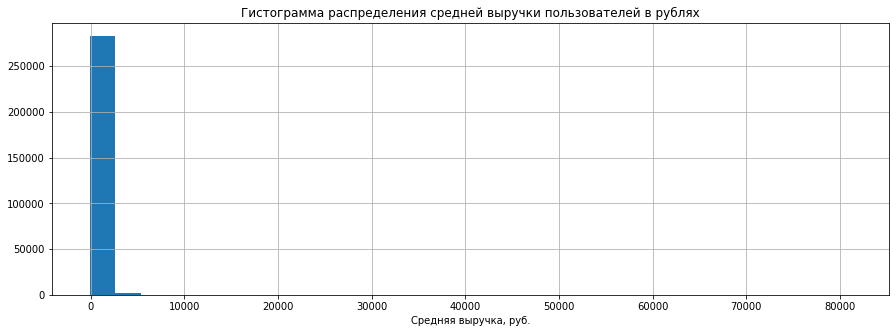

Средняя выручка пользователей 548 руб


In [14]:
# Гистограмма средней выручки пользователей в рублях
plt.figure(figsize=(15, 5))
df[df['currency_code'] == 'rub']['revenue'].hist(bins=30)
plt.xlabel('Средняя выручка, руб.')
plt.title('Гистограмма распределения средней выручки пользователей в рублях')
plt.show()

# Расчет и вывод на экран средней выручки пользователей в рублях
mean_rev_rub = round(df[df['currency_code'] == 'rub']['revenue'].mean())
print(f'Средняя выручка пользователей {mean_rev_rub} руб')

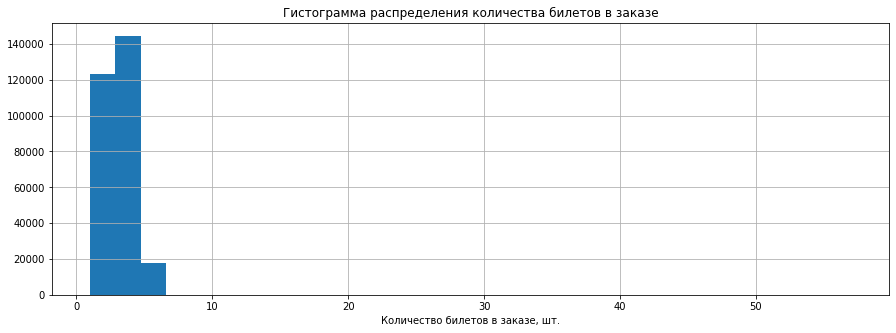

Среднее количество билетов в заказе 3 шт


In [15]:
# Гистограмма количества билетов в заказе
plt.figure(figsize=(15, 5))
df[df['currency_code'] == 'rub']['tickets_count'].hist(bins=30)
plt.xlabel('Количество билетов в заказе, шт.')
plt.title('Гистограмма распределения количества билетов в заказе')
plt.show()

# Расчет и вывод на экран кол-ва билетов в заказе
mean_cnt_rub = round(df[df['currency_code'] == 'rub']['tickets_count'].mean())
print(f'Среднее количество билетов в заказе {mean_cnt_rub} шт')

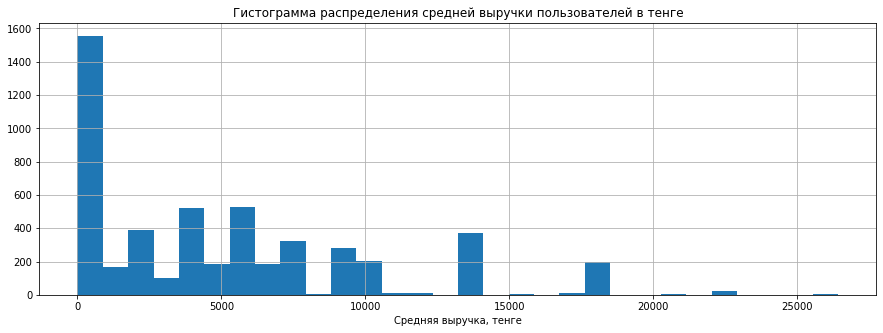

Средняя выручка пользователей 4995 тенге


In [16]:
# Гистограмма средней выручки пользователей в тенге
plt.figure(figsize=(15, 5))
df[df['currency_code'] == 'kzt']['revenue'].hist(bins=30)
plt.xlabel('Средняя выручка, тенге')
plt.title('Гистограмма распределения средней выручки пользователей в тенге')
plt.show()

# Расчет и вывод на экран средней суммарной активности пользователей в тенге
mean_rev_kzt = round(df[df['currency_code'] == 'kzt']['revenue'].mean())
print(f'Средняя выручка пользователей {mean_rev_kzt} тенге')

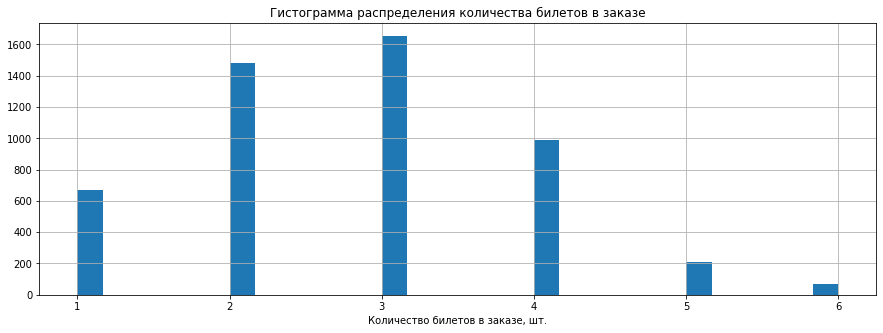

Среднее количество билетов в заказе 3 шт


In [17]:
# Гистограмма количества билетов в заказе
plt.figure(figsize=(15, 5))
df[df['currency_code'] == 'kzt']['tickets_count'].hist(bins=30)
plt.xlabel('Количество билетов в заказе, шт.')
plt.title('Гистограмма распределения количества билетов в заказе')
plt.show()

# Расчет и вывод на экран кол-ва билетов в заказе
mean_cnt_kzt = round(df[df['currency_code'] == 'kzt']['tickets_count'].mean())
print(f'Среднее количество билетов в заказе {mean_cnt_kzt} шт')

In [18]:
# Для revenue заменим выбросы на 99-ый процентиль
for currency in ['rub', 'kzt']:
    mask = df['currency_code'] == currency
    upper_99 = df[mask]['revenue'].quantile(0.99)
    df.loc[mask, 'revenue'] = df.loc[mask, 'revenue'].clip(upper=upper_99)

In [19]:
# Проверяем полные дубликаты
df.duplicated().sum()

0

In [20]:
# Проверяем неявные дубликаты
# Колонки, которые определяют уникальность бронирования
booking_columns = ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'cinema_circuit', 'currency_code', 'service_name',
                  'device_type_canonical', 'region_name', 'city_name', 'organizers', 'venue_name', 'event_name', 'revenue']
duplicates = df.duplicated(subset=booking_columns).sum()
print(f'Число неявных дубликатов: {duplicates}')

# Удаляем неявные дубликаты
df.drop_duplicates(subset=booking_columns, keep='first', inplace=True)

print('Число неявных дубликатов после удаления', df.duplicated(subset=booking_columns).sum())

Число неявных дубликатов: 40
Число неявных дубликатов после удаления 0


In [21]:
# Преобразовываем типы данных
df[['created_dt_msk', 'created_ts_msk']] = df[['created_dt_msk', 'created_ts_msk']].astype('datetime64[ns]')

for column in ['age_limit', 'tickets_count']:
    df[column] = pd.to_numeric(df[column], downcast='integer')
    
for column in ['revenue', 'total']:
    df[column] = pd.to_numeric(df[column], downcast='float')
    
tenge_df['data'] = tenge_df['data'].astype('datetime64[ns]')

tenge_df['nominal'] = pd.to_numeric(tenge_df['nominal'], downcast='integer')

tenge_df['curs'] = pd.to_numeric(tenge_df['curs'], downcast='float')

In [22]:
# Проверим типы данных
display(df.dtypes, tenge_df.dtypes)

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                           int8
currency_code                     object
device_type_canonical             object
revenue                          float32
service_name                      object
tickets_count                       int8
total                            float32
days_since_prev                  float64
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int64
venue_id                           int64
venue_name                        object
venue_address                     object
dtype: object

data       datetime64[ns]
nominal              int8
curs              float32
cdx                object
dtype: object

In [23]:
# Объяединим основной датафрейм с датафреймом по курсу валюты
tenge_df = tenge_df.rename(columns={'data':'created_dt_msk', 'cdx':'currency_code'})
df = df.merge(tenge_df, on=['created_dt_msk', 'currency_code'], how='left')

In [24]:
# Копируем revenue
df['revenue_rub'] = df['revenue'].copy()

# Приводим выручку с заказа к единой валюте
mask_kzt = df['currency_code'] == 'kzt'
df.loc[mask_kzt, 'revenue_rub'] = df.loc[mask_kzt, 'revenue'] * df.loc[mask_kzt, 'curs'] / 100

In [25]:
# Создаем новые столбцы
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

df['month'] = df['created_dt_msk'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

df['season'] = df['month'].apply(get_season)

In [26]:
# Выводим информацию о кол-ве и проценте удаленных строк
old_rows = df_copy.shape[0]
new_rows = df.shape[0]
print(f"Исходное количество строк: {old_rows}")
print(f"Конечное количество строк: {new_rows}")
print(f"Удалено строк: {old_rows - new_rows}")
print(f"Процент удалённых строк: {(old_rows - new_rows)/old_rows*100:.2f}%")

Исходное количество строк: 290611
Конечное количество строк: 290571
Удалено строк: 40
Процент удалённых строк: 0.01%


В результате предобработки данных были выполнены следующие действия:

- Объединили все датасеты в один.
- Проверили данные на пропуски. Пропущенные значения в столбце `days_since_prev` оставили, а в остальных удалили.
- В столбце `revenue` были найдены выбросы, такие значения заменили на 99-ый процентиль.
- Явных дубликатов в данных не оказалось, но были найдены неявные (40 шт), их удалили.
- Изменили тип данных столбцов `created_dt_msk`, `created_ts_msk`, `data` на `datetime64`. Понизили разрядность у столбцов `age_limit`, `tickets_count`, `revenue`, `total nominal`, `curs`.
- Созданы новые столбцы:
  - `revenue_rub` — выручка с заказов в одной валюте;
  - `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие;
  - `month` — месяц оформления заказа;
  - `season` — столбец с информацией о сезонности.
  
Изначально было 290611 строк, после обработки данных осталось 290571 строка, удалили 40 строк, что составляет 0.1%.

## 3. Исследовательский анализ данных

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

In [27]:
# Количество заказов в каждом месяце в разрезе тип мероприятия
monthly = df.groupby('month')['order_id'].count()
print(monthly)

month
6      34497
7      40916
8      45004
9      69960
10    100194
Name: order_id, dtype: int64


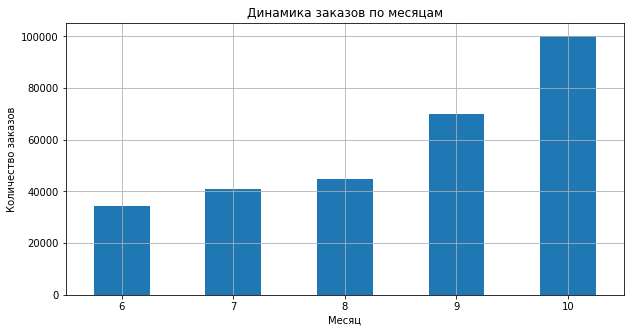

In [28]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
monthly.plot(kind='bar',
               rot=0,
               legend=False,
               title='Динамика заказов по месяцам'
)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid()
plt.show()

In [29]:
# Отфильтруем только лето и осень 2024
df_season = df[df['season'].isin(['лето', 'осень'])].copy()

# Функция для расчёта долей
def plot_season_comparison(df_season, column, title):
    # Считаем количество заказов
    season_counts = df_season.groupby([column, 'season'])['order_id'].count().unstack()
    
    # Переводим в доли
    season_shares = season_counts.div(season_counts.sum(axis=0), axis=1)
    
    # Строим столбчатую диаграмму
    season_shares.plot(kind='bar', figsize=(10, 5))
    plt.title(f'Доли заказов по сезонам: {title}')
    plt.xlabel(title)
    plt.ylabel('Доля заказов')
    plt.legend(title='Сезон')
    plt.xticks(rotation=0)
    plt.show()
    
    return season_shares

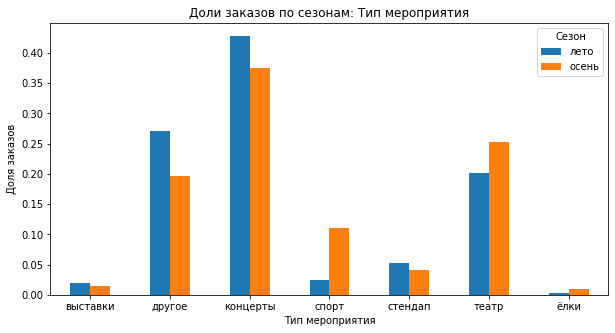

season,лето,осень
event_type_main,,
выставки,0.020064,0.014322
другое,0.270444,0.195629
концерты,0.427979,0.374543
спорт,0.025021,0.111035
стендап,0.053157,0.041092
театр,0.201043,0.253312
ёлки,0.002292,0.010067


In [30]:
# Тип мероприятия
plot_season_comparison(df_season, 'event_type_main', 'Тип мероприятия')

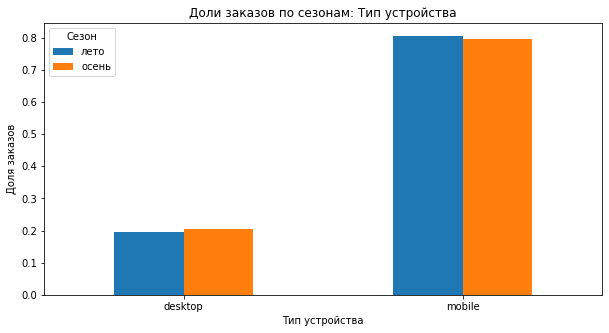

season,лето,осень
device_type_canonical,,
desktop,0.194566,0.203827
mobile,0.805434,0.796173


In [31]:
# Тип устройства
plot_season_comparison(df_season, 'device_type_canonical', 'Тип устройства')

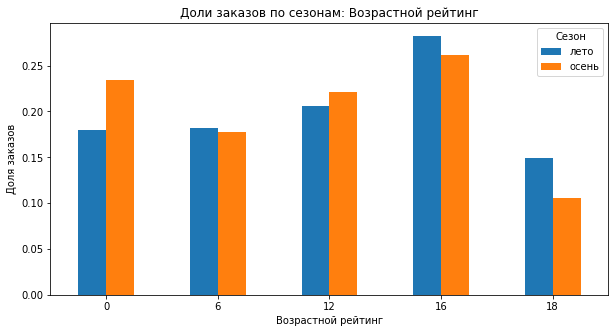

season,лето,осень
age_limit,,
0,0.179451,0.234294
6,0.182391,0.177422
12,0.206001,0.221341
16,0.282435,0.261769
18,0.149721,0.105175


In [32]:
# Возрастной рейтинг
plot_season_comparison(df_season, 'age_limit', 'Возрастной рейтинг')

In [33]:
# Среднее значение выручки с одного билета в разрезе тип мероприятия летом и осенью
ticket_revenue_season = df_season.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()

# Расчёт относительного изменения (осень к лету)
ticket_revenue_season['perc'] = (ticket_revenue_season['осень'] / ticket_revenue_season['лето'])
print(ticket_revenue_season)

season                 лето       осень      perc
event_type_main                                  
выставки          86.416199   90.918068  1.052095
другое            80.536301   76.978859  0.955828
концерты         310.157440  274.529999  0.885131
спорт             52.563679   50.457333  0.959928
стендап          221.714371  237.000443  1.068945
театр            219.761993  180.574371  0.821682
ёлки             274.695435  233.365433  0.849542


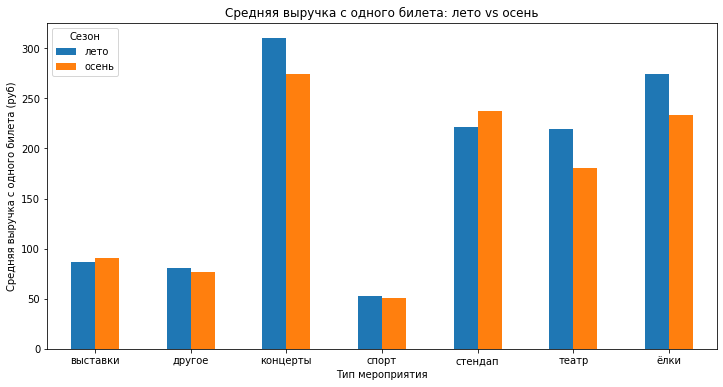

In [34]:
# Строим столбчатую диаграмму
ticket_revenue_season[['лето', 'осень']].plot(kind='bar', figsize=(12, 6))
plt.title('Средняя выручка с одного билета: лето vs осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с одного билета (руб)')
plt.xticks(rotation=0)
plt.legend(title='Сезон')
plt.show()

По графику динамики заказов по месяцам видно, что происходит рост количества заказов с июня по октябрь. Максимальный рост фиксируется в сентябре и октябре, что подтверждает сезонность: осенью спрос на билеты значительно увеличивается. По столбчатой диаграмме доли заказов по сезонам в разрезе тип мероприятия видно, что наибольшая доля летом и осенью получается в категории концерты, однако доля осенью снижается (с 42.8% до 37.5%). Также доля заказов осенью в категории спорт, театр, елки больше чем летом. По столбчатой диаграмме доли заказов по сезонам в разрезе тип устройства значения достаточно стабильны и приблизительно одинаковы летом и осенью для мобильных и десктопных устройств. Мобильные устройства остаются основным каналом продаж. По столбчатой диаграмме доли заказов по сезонам в разрезе возрастной рейтинг видно, что осенью растет доля заказов с возрастным рейтингом 0+ и 12+, но снижается доля для 6+, 16+ и 18+. Средняя выручка с одного билета для категорий выставки и стендап растет осенью (+6.9% и +5.2%), однако категории театр, елки и концерты показывают значительное снижение средней выручки ( -17.8%, -15.0%, -11.5%).

### 3.2. Осенняя активность пользователей

In [35]:
# Отобрали данные только за осень
df_fall = df[df['season'].isin(['осень'])].copy()

In [36]:
# Создаем сводную таблицу
table = pd.pivot_table(df_fall, index='created_dt_msk', 
                       values=['order_id', 'user_id', 'one_ticket_revenue_rub'], 
                       aggfunc={'order_id':'count', 'user_id':'nunique', 'one_ticket_revenue_rub':'mean'})
table['order_per_user'] = table['order_id'] / table['user_id']
print(table)

                one_ticket_revenue_rub  order_id  user_id  order_per_user
created_dt_msk                                                           
2024-09-01                  206.458817      1348      569        2.369069
2024-09-02                  193.387650      1391      580        2.398276
2024-09-03                   81.532295      5124      783        6.544061
2024-09-04                  180.504776      1784      688        2.593023
2024-09-05                  192.772461      1960      745        2.630872
...                                ...       ...      ...             ...
2024-10-27                  189.513428      2865     1039        2.757459
2024-10-28                  174.212143      2859      988        2.893725
2024-10-29                  187.656448      2888     1005        2.873632
2024-10-30                  187.403152      2959     1049        2.820782
2024-10-31                  152.937347      5991     1282        4.673167

[61 rows x 4 columns]


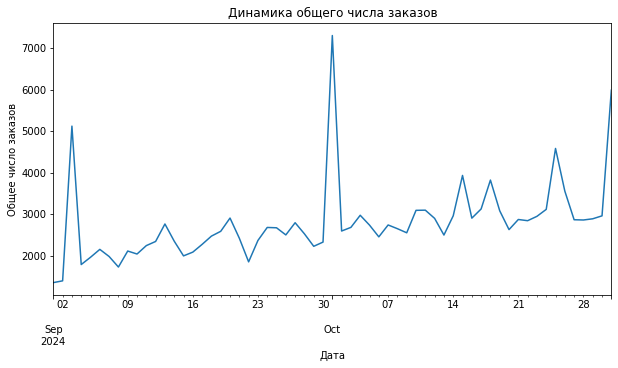

In [37]:
# Строим линейный график
plt.figure(figsize=(10, 5))
table['order_id'].plot.line()
plt.xlabel('Дата')
plt.ylabel('Общее число заказов')
plt.title('Динамика общего числа заказов')
plt.show()

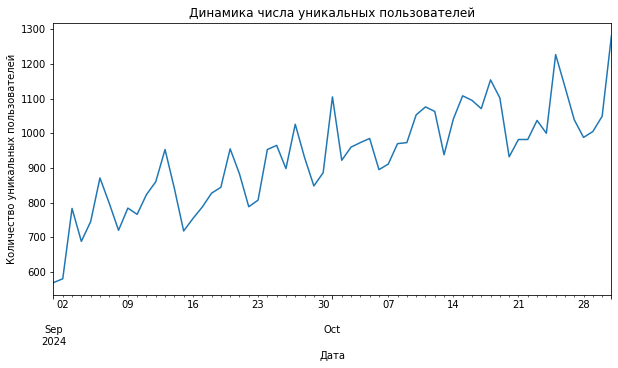

In [38]:
# Строим линейный график
plt.figure(figsize=(10, 5))
table['user_id'].plot.line()
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей')
plt.title('Динамика числа уникальных пользователей')
plt.show()

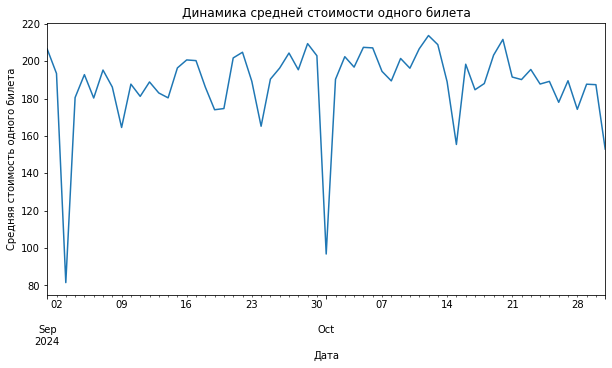

In [39]:
# Строим линейный график
plt.figure(figsize=(10, 5))
table['one_ticket_revenue_rub'].plot.line()
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость одного билета')
plt.title('Динамика средней стоимости одного билета')
plt.show()

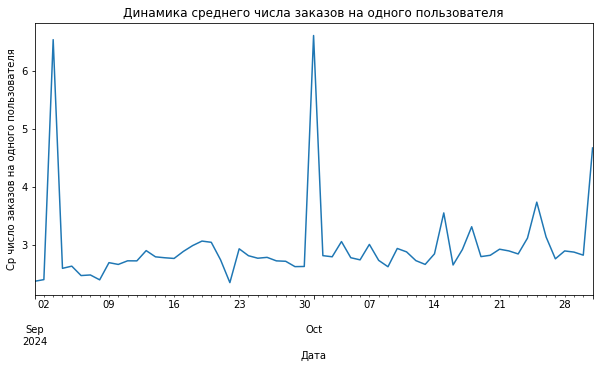

In [40]:
# Строим линейный график
plt.figure(figsize=(10, 5))
table['order_per_user'].plot.line()
plt.xlabel('Дата')
plt.ylabel('Ср число заказов на одного пользователя')
plt.title('Динамика среднего числа заказов на одного пользователя')
plt.show()

In [41]:
# Добавляем день недели
df_fall['weekday'] = pd.to_datetime(df_fall['created_dt_msk']).dt.dayofweek  # 0=пн, 6=вс
df_fall['is_weekend'] = df_fall['weekday'] >= 5

week = df_fall.groupby('is_weekend').agg({'order_id':'count', 'user_id':'nunique', 'revenue_rub':'sum'})
week.index = ['Будни', 'Выходные']
print(week)

          order_id  user_id  revenue_rub
Будни       129036    13279   63037496.0
Выходные     41118     7202   22778718.0


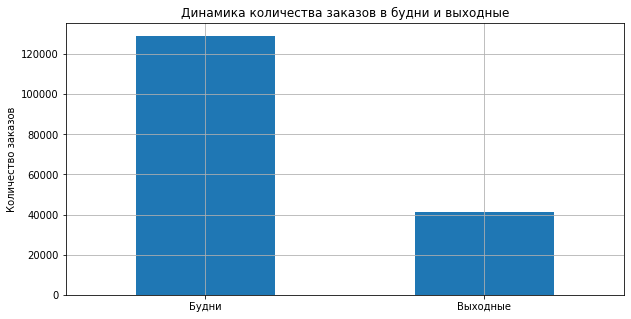

In [42]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
week['order_id'].plot(kind='bar',
               rot=0,
               legend=False,
               title='Динамика количества заказов в будни и выходные'
)
plt.ylabel('Количество заказов')
plt.grid()
plt.show()

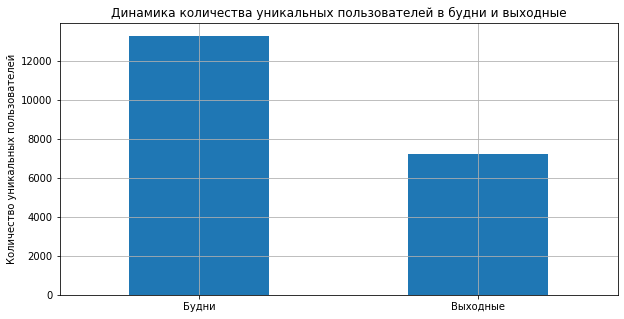

In [43]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
week['user_id'].plot(kind='bar',
               rot=0,
               legend=False,
               title='Динамика количества уникальных пользователей в будни и выходные'
)
plt.ylabel('Количество уникальных пользователей')
plt.grid()
plt.show()

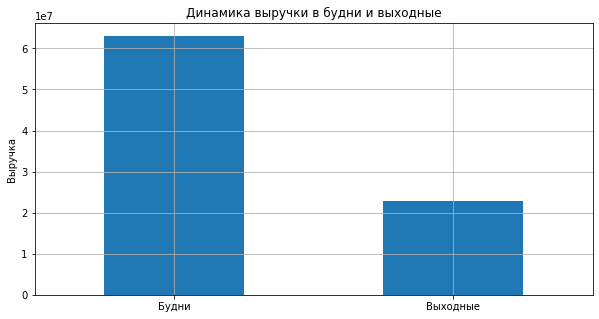

In [44]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
week['revenue_rub'].plot(kind='bar',
               rot=0,
               legend=False,
               title='Динамика выручки в будни и выходные'
)
plt.ylabel('Выручка')
plt.grid()
plt.show()

По линейной диаграмме динамики общего числа заказов видны колебания, пиковые значения приходятся на начало сентября, начало и конец октября. Это может быть связано с выходом новых мероприятий или сезонным ростом спроса. Число уникальных пользователей растет к концу октбяря, но на графике видны заметные колебания, что может говорить о неравномерной активности аудитории. На графике средней смтоимости одного билета виден значительный резкий спад в начале сентября и октября, возможно это связано с проведением большего количества недорогих мероприятий. На графике среднего числа заказов на одного пользователя также видны колебания, пики приходятся на начало сентября, начало и конец октября, что совпадает с графиком общего числа заказов. Динамика количества заказов, количества пользователей и значения выручки в будни и выходные сохраняют похожие тенденции: значения в будние дни значительно превышают значения в выходные.

### 3.3. Популярные события и партнёры

In [45]:
# Распределение по регионам
regions = df.groupby('region_name').agg({'event_id':'nunique', 'order_id':'count'})
regions['events_share'] = regions['event_id'] / regions['event_id'].sum()
regions['orders_share'] = regions['order_id'] / regions['order_id'].sum()
print(regions)

                      event_id  order_id  events_share  orders_share
region_name                                                         
Белоярская область          57       199      0.002542      0.000685
Берестовский округ          39       395      0.001739      0.001359
Берёзовская область        166      1282      0.007402      0.004412
Боровлянский край           97      1721      0.004325      0.005923
Верховинская область         8        50      0.000357      0.000172
...                        ...       ...           ...           ...
Шанырский регион            28      2881      0.001248      0.009915
Широковская область       1233     16457      0.054978      0.056637
Яблоневская область        535      6179      0.023855      0.021265
Ягодиновская область       120      1044      0.005351      0.003593
Яснопольский округ           5        21      0.000223      0.000072

[81 rows x 4 columns]


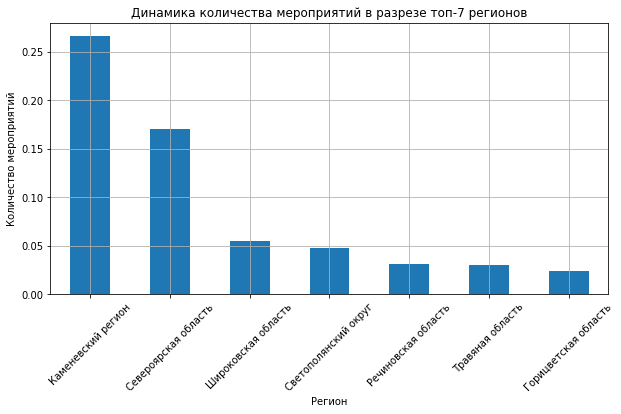

In [46]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
regions['events_share'].sort_values(ascending=False).head(7).plot(kind='bar',
               rot=45,
               legend=False,
               title='Динамика количества мероприятий в разрезе топ-7 регионов'
)
plt.xlabel('Регион')
plt.ylabel('Количество мероприятий')
plt.grid()
plt.show()

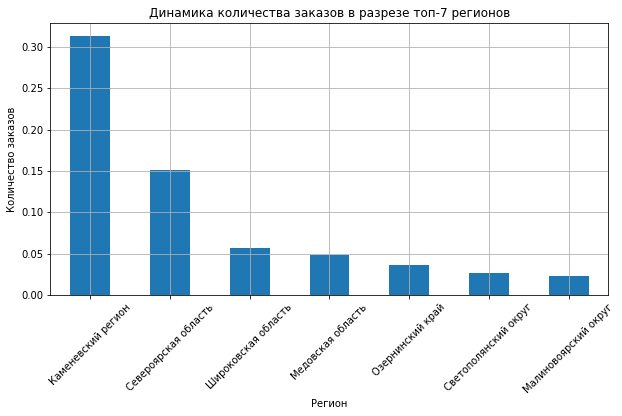

In [47]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
regions['orders_share'].sort_values(ascending=False).head(7).plot(kind='bar',
               rot=45,
               legend=False,
               title='Динамика количества заказов в разрезе топ-7 регионов'
)
plt.xlabel('Регион')
plt.ylabel('Количество заказов')
plt.grid()
plt.show()

In [48]:
# Распределение по билетным партнерам
partners = df.groupby('service_name').agg({'event_id':'nunique', 'order_id':'count', 'revenue_rub':'sum'})
print(partners)

                        event_id  order_id   revenue_rub
service_name                                            
Crazy ticket!                257       790  4.544956e+05
Show_ticket                  295      2200  1.732064e+06
Билет по телефону             20        85  7.244740e+04
Билеты без проблем          4255     63503  2.598537e+07
Билеты в интернете             1         4  5.482300e+02
Билеты в руки               3538     40336  1.334022e+07
Быстробилет                  255      2002  1.584263e+06
Быстрый кассир                20       381  4.018315e+05
Весь в билетах               867     16848  1.762237e+07
Восьмёрка                    144      1118  6.886588e+05
Вперёд!                       37        80  3.153965e+04
Выступления.ру               151      1616  1.285446e+06
Городской дом культуры       378      2733  1.656743e+06
Дом культуры                 274      4502  4.590028e+06
Дырокол                        2        74  1.143611e+05
За билетом!                  23

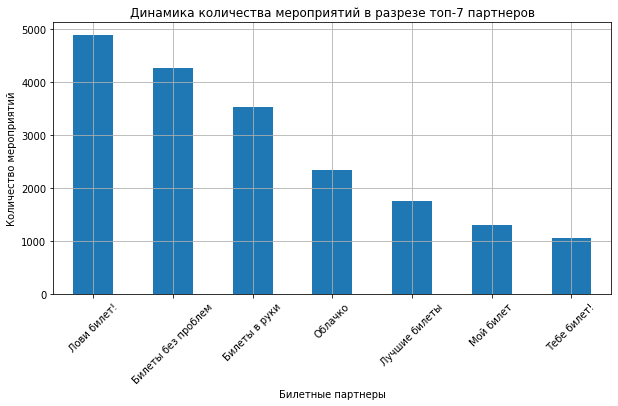

In [49]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
partners['event_id'].sort_values(ascending=False).head(7).plot(kind='bar',
               rot=45,
               legend=False,
               title='Динамика количества мероприятий в разрезе топ-7 партнеров'
)
plt.xlabel('Билетные партнеры')
plt.ylabel('Количество мероприятий')
plt.grid()
plt.show()

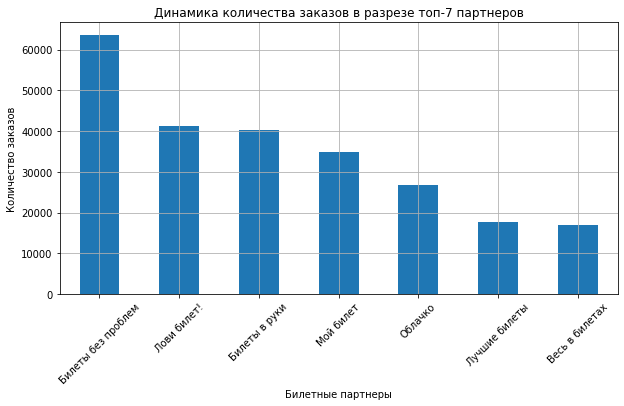

In [50]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
partners['order_id'].sort_values(ascending=False).head(7).plot(kind='bar',
               rot=45,
               legend=False,
               title='Динамика количества заказов в разрезе топ-7 партнеров'
)
plt.xlabel('Билетные партнеры')
plt.ylabel('Количество заказов')
plt.grid()
plt.show()

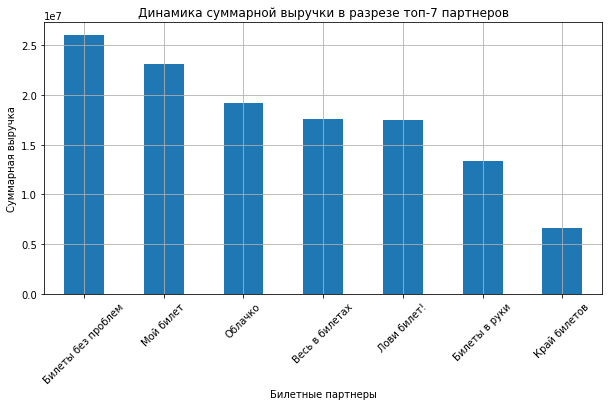

In [51]:
# Строим столбчатую диаграмму
plt.figure(figsize=(10, 5))
partners['revenue_rub'].sort_values(ascending=False).head(7).plot(kind='bar',
               rot=45,
               legend=False,
               title='Динамика суммарной выручки в разрезе топ-7 партнеров'
)
plt.xlabel('Билетные партнеры')
plt.ylabel('Суммарная выручка')
plt.grid()
plt.show()

Лидеры по количеству мероприятий: Каменевский регион, Североярская область, Широковская область. Лидеры по количеству заказов: Каменевский регион, Североярская область, Широковская область. Топ регионов с большим количеством мероприятий совпадает с топом регионов с большим количеством заказов. Также заметно явно преобладание значений в Каменевском районе: количество мероприятий составляет более 25%, а количество заказов более 30%. Распределение неравномерное: несколько топ регионов концентрируют основную долю активности, а большинство регионов имеют незначительный вклад. В разрезе билетных партнеров видно, что лидер по суммарной выручке и количеству заказов это билетный партнер "Билеты без проблем", по количеству мероприятий данных партнер находится на втором месте, а лидером является "Лови билет!", который также входит в топ по выручке и количеству заказов.

## 4. Статистический анализ данных

Среднее количество заказов на пользователя:

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0):  Среднее количество заказов на пользователя у мобильных устройств такое же, как и у стационарных.

- Альтернативная гипотеза (Н1): Среднее количество заказов на пользователя у мобильных устройств выше, чем у стационарных.

Будем использовать t-тест Уэлча, т.к. нам неизвестно соотношение выборочных дисперсий.

In [52]:
users_fall = df_fall.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
mobile_orders = users_fall[users_fall['device_type_canonical'] == 'mobile']['order_id']
desktop_orders = users_fall[users_fall['device_type_canonical'] == 'desktop']['order_id']

results = st.ttest_ind(mobile_orders, desktop_orders, alternative='greater')
p_value = results.pvalue

def print_stattest_results(p_value, alpha=0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value)

mobile_mean_orders = round(mobile_orders.mean(), 2)
desktop_mean_orders = round(desktop_orders.mean(), 2)

print(f'Среднее количество заказов на пользователя у мобильных устройств {mobile_mean_orders}')
print(f'Среднее количество заказов на пользователя у стационарных устройств {desktop_mean_orders}')

Полученное значение p_value=0.00846501509546377 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Среднее количество заказов на пользователя у мобильных устройств 9.51
Среднее количество заказов на пользователя у стационарных устройств 7.07


Гипотеза о том, что среднее количество заказов на пользователя у мобильных устройств выше, чем у стационарных, оказала статистически значимое влияние на рост метрики среднее количество заказов на пользователя. Значение alpha=0.05, p_value=0.00846501509546377, след-но, p_value < alpha, значит разница статистически значима. Нулевая гипотеза о том, что пользователи мобильных устройств не увеличивают среднее количество заказов на пользователя, отвергается.

Среднее время между заказами:

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0):  Среднее время между заказами пользователей мобильных устройств такое же, как и у стационарных.

- Альтернативная гипотеза (Н1): Среднее время между заказами пользователей мобильных устройств выше, чем у стационарных.

Будем использовать t-тест Уэлча, т.к. нам неизвестно соотношение выборочных дисперсий.

In [53]:
# Удаляем пропуски
df_between = df_fall[df_fall['days_since_prev'].notna()].copy()

mobile_between = df_between[df_between['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_between = df_between[df_between['device_type_canonical'] == 'desktop']['days_since_prev']

results = st.ttest_ind(mobile_between, desktop_between, alternative='greater')
p_value = results.pvalue

def print_stattest_results(p_value, alpha=0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value)

mobile_mean_between = round(mobile_between.mean(), 2)
desktop_mean_between = round(desktop_between.mean(), 2)

print(f'Среднее количество заказов на пользователя у мобильных устройств {mobile_mean_between}')
print(f'Среднее количество заказов на пользователя у стационарных устройств {desktop_mean_between}')

Полученное значение p_value=1.364006016847741e-20 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Среднее количество заказов на пользователя у мобильных устройств 3.78
Среднее количество заказов на пользователя у стационарных устройств 3.04


Гипотеза о том, что среднее время между заказами пользователей мобильных устройств выше, чем у стационарных, оказала статистически значимое влияние на рост метрики среднее время между заказами. Значение alpha=0.05, p_value=1.36400601684778e-20, след-но, p_value < alpha, значит разница статистически значима. Нулевая гипотеза о том, что пользователи мобильных устройств не увеличивают среднее время между заказами, отвергается.

## 5. Итоговые выводы

В работе использовались три датасета: таблица с заказами билетов (290 849 записей), таблица с информацией о мероприятиях (22 427 записей), таблица с курсом казахстанского тенге к российскому рублю (357 записей). После объединения и предобработки итоговый датасет содержит 290 571 строку (потеряно 0.1% данных).

Самыми востребованными мероприятиями являются концерты, они занимают лидирующую долю как летом, так и осенью. Осенью наблюдается значительный рост количества заказов, максимум приходится на сентябрь и октябрь. При этом доля концертов осенью снижается с 42,8% до 37,5%, тогда как доля театра и спорта растет. Средняя выручка с одного билета осенью снижается по большинству категорий. Исключение составляют выставки и стендап, где средний чек вырос на 5,2% и 6,9% соответственно. По динамике пользовательской активности число уникальных пользователей растёт к концу октября, однако наблюдаются заметные колебания, что говорит о неравномерной активности аудитории. Также выявлена недельная цикличность: в будние дни количество заказов, пользователей и выручка выше, чем в выходные. Топ регионы по количеству мероприятий и заказов совпадают. Каменевский регион значительно доминирует над остальными. Среди билетных партнеров лидер по выручке и количеству заказов "Билеты без проблем", а по количеству мероприятий "Лови билет!".

Первая гипотеза о том, что среднее количество заказов на пользователя у мобильных устройств выше, чем у стационарных, подтвердилась. Нулевая гипотеза отвергается. Среднее количество заказов на пользователя у мобильных устройств составляет 9,51, а у стационарных — 7,07. Вторая гипотеза о том, что среднее время между заказами у мобильных пользователей выше, также подтвердилась. Нулевая гипотеза также отвергается. Мобильные пользователи делают паузу между заказами в среднем 3,78 дня, тогда как пользователи стационарных устройств — 3,04 дня.

Рекомендации:

- усилить мобильное направление: пользователи мобильных устройств приносят больше заказов;
- осенью средний чек падает, возможно, стоит пересмотреть ценообразование на популярные категории;
- активность в будние дни в разы выше, чем в выходные: стоит проводить маркетинговые кампании именно в будни;
- существует неравномерность между регионами: стоит разработать маркетинговые стратегии для роста продаж в других регионах.